In [1]:
import matplotlib
import pandas as pd
import numpy as np
import boost_histogram as bh
import dask.dataframe as dd
import tqdm
import h5py
import glob
import pickle
import os

import matplotlib.pyplot as plt

# Estimation of the Radiogenic Nuclear Recoil Background

## Neutron simulations with Geant4 (and post-processing)
We directly simulate only the neutron interactions within the TPC volume using Geant4. All other interactions (e.g. gamma, beta) don't lead to nuclear recoils and are thus not simulated. The neutron spectra inside the Geant4 simulation are taken from SOURCES-4A simulations of the detector materials.

In [3]:
#data_folder = './20260116'
data_folder='/cloud/wwu1/p_agweinheimer/AGW_LowRad/home/l_alth03/simulations/HermeticTPC/20260116'
fuse_files = glob.glob(f'{data_folder}/*_fuse.h5')
parquet_files = glob.glob(f'{data_folder}/*_parquet.h5')

keys = list(h5py.File(fuse_files[0], 'r').keys())
fuse_keys = dd.read_hdf(fuse_files[0], key=keys[0]).columns.values

assert len(keys) == 1, "Expected exactly one key in fuse files."

print(f"Found {len(fuse_files)} fuse files and {len(parquet_files)} parquet files.")
print(f"Fuse file keys: {list(fuse_keys)}")

Found 10 fuse files and 10 parquet files.
Fuse file keys: ['macro', 'runid', 'x', 'y', 'z', 'ed', 'nestid', 'cluster_id', 'eventid', 'trackid', 't', 'A', 'Z', 'x_pri', 'y_pri', 'z_pri', 'time', 'endtime', 'n_clusters']


In [4]:
def get_dds(data_folder, file_type='fuse'):
    dds = {}
    fuse_files = glob.glob(f'{data_folder}/*_{file_type}.h5')

    for file in fuse_files:
        keys = list(h5py.File(file, 'r').keys())
        assert len(keys) == 1, "Expected exactly one key in fuse files."
        dds[keys[0]] = dd.read_hdf(file, key=keys[0])

    return dds

dds = get_dds(data_folder, file_type='fuse')

In [5]:
dds["run_Copper_Th232"].head()

,macro,runid,x,y,z,ed,nestid,cluster_id,eventid,trackid,t,A,Z,x_pri,y_pri,z_pri,time,endtime,n_clusters
0,run_Copper_Th232,42,1286.701172,-634.603394,1219.108521,45.677933,0,3,0,2,0.000006,0,0,1353.058472,-649.079468,1280.377441,988663514,988663514,1
1,run_Copper_Th232,42,-1188.310791,644.218506,888.715515,177.290390,8,8,1,2,0.071548,0,0,-1367.909912,616.471436,810.128784,1854650863,1854650863,42
2,run_Copper_Th232,42,-1185.357788,644.231445,890.621887,32.154381,8,7,1,2,0.059442,0,0,-1367.909912,616.471436,810.128784,1854650863,1854650863,42
3,run_Copper_Th232,42,-1181.543213,645.317505,889.075684,33.287785,8,6,1,2,0.045242,0,0,-1367.909912,616.471436,810.128784,1854650863,1854650863,42
4,run_Copper_Th232,42,-1175.796265,643.248962,876.984253,4.411160,0,13,1,4,0.000000,0,0,-1367.909912,616.471436,810.128784,1854650863,1854650863,42


Load run_Sapphire_U238


100%|██████████| 99/99 [02:33<00:00,  1.55s/it]


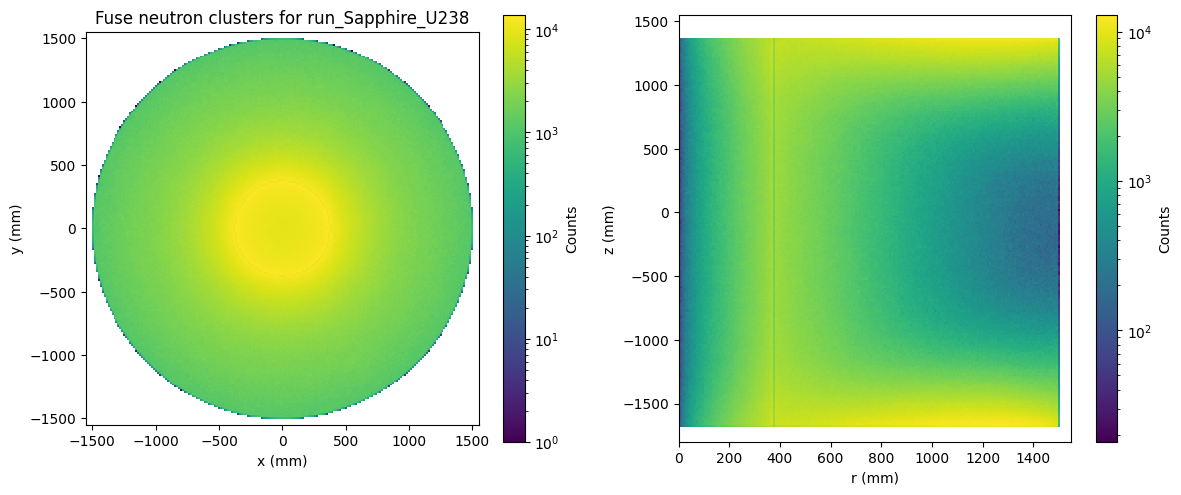

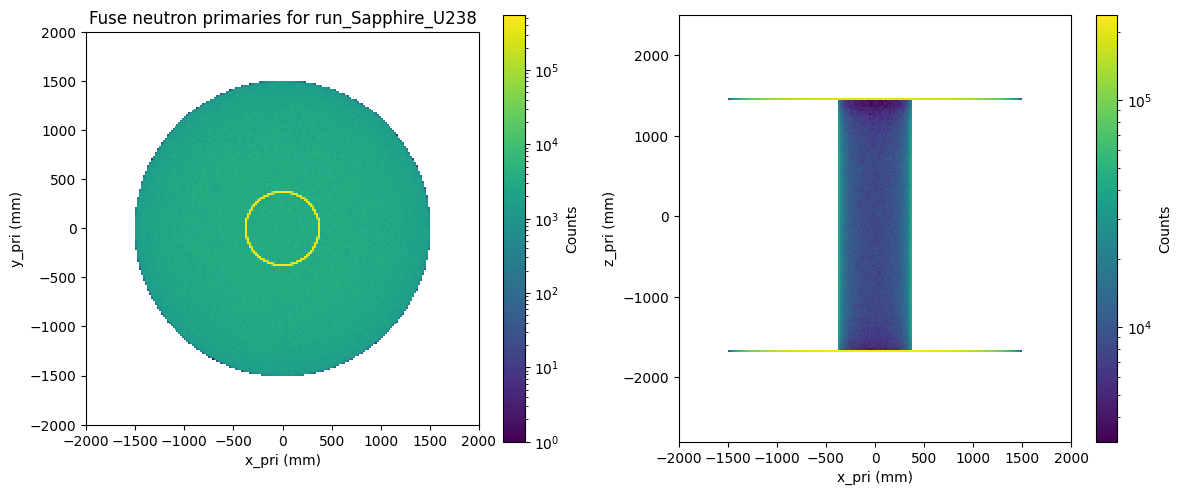

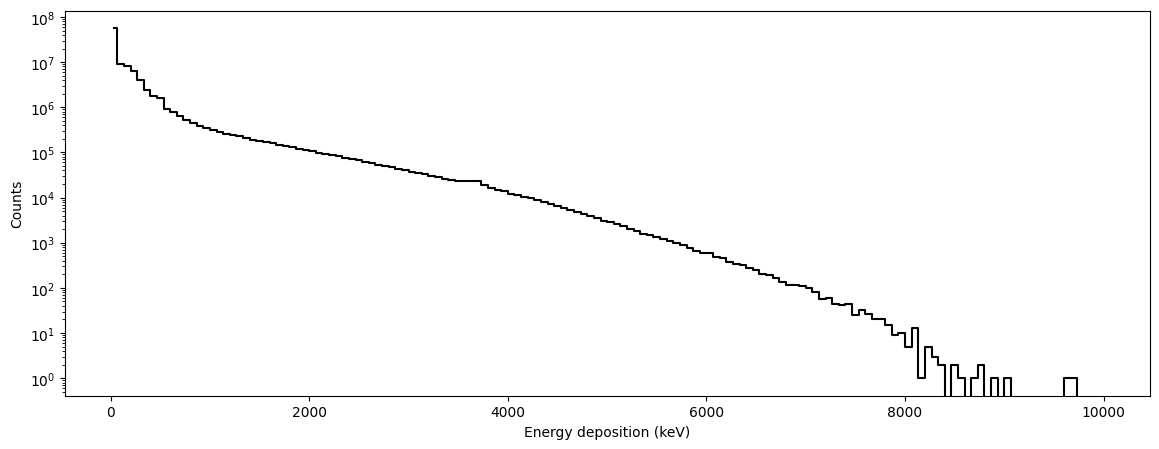

Load run_Teflon_Th232


100%|██████████| 72/72 [02:10<00:00,  1.82s/it]


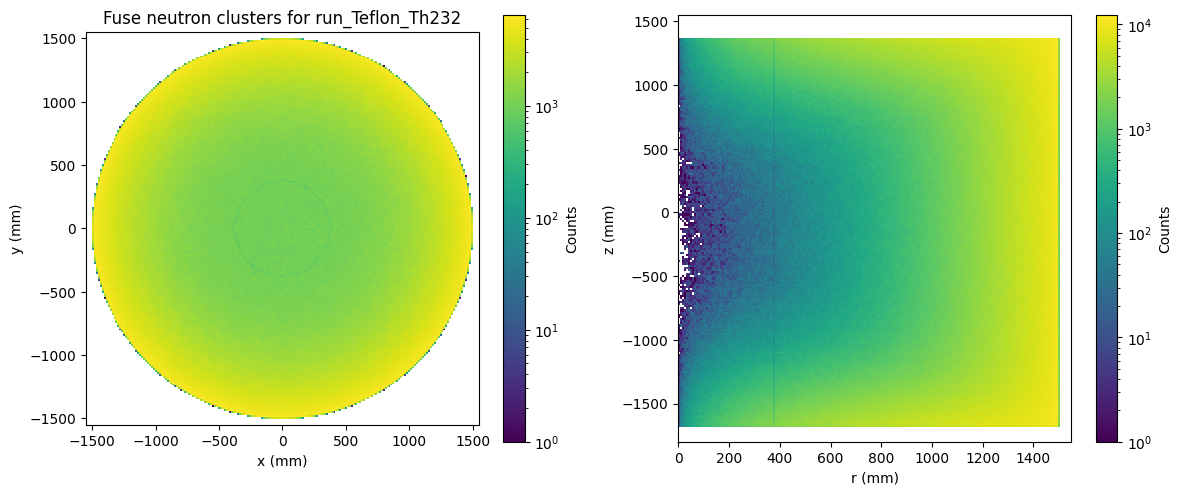

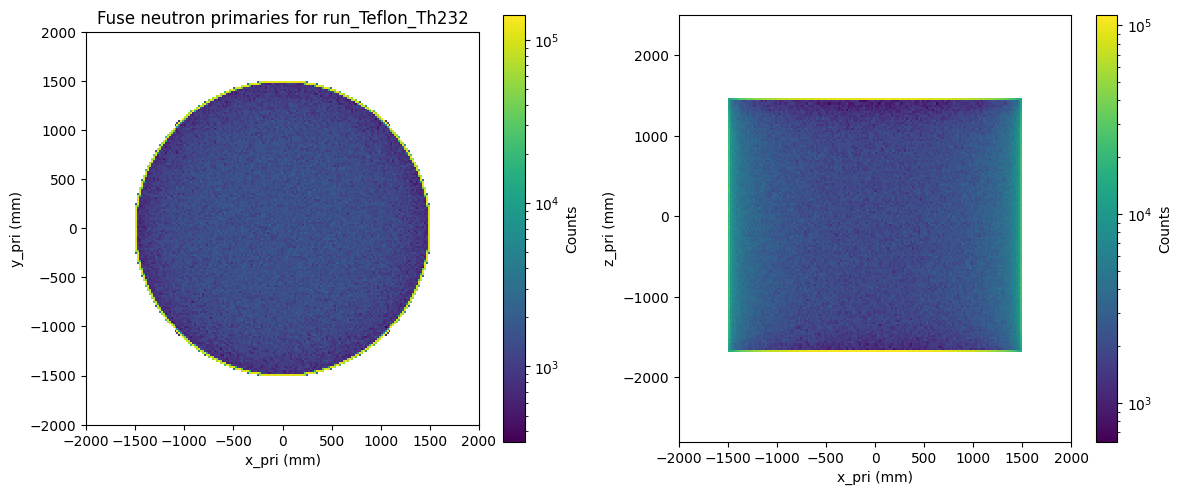

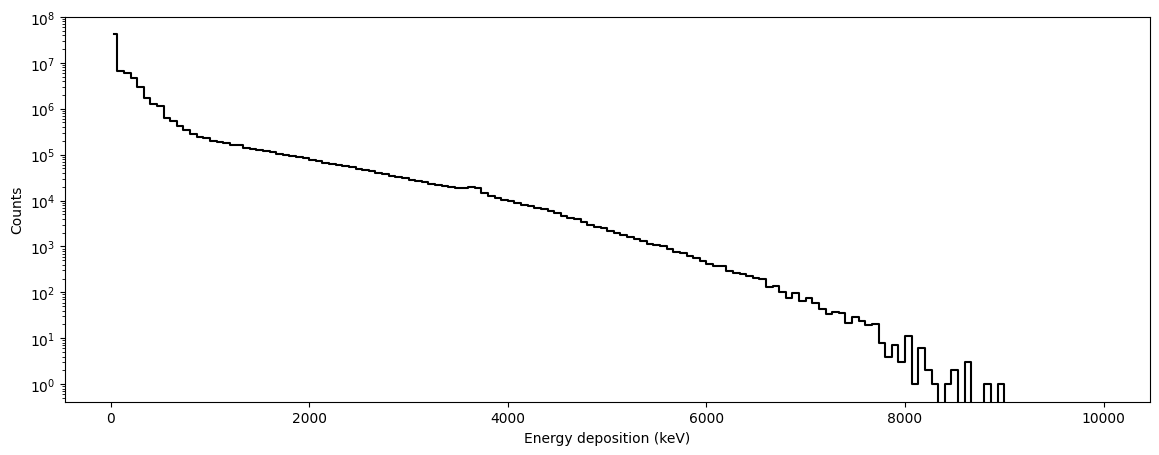

Load run_Cryostat_Th232


100%|██████████| 37/37 [01:06<00:00,  1.79s/it]


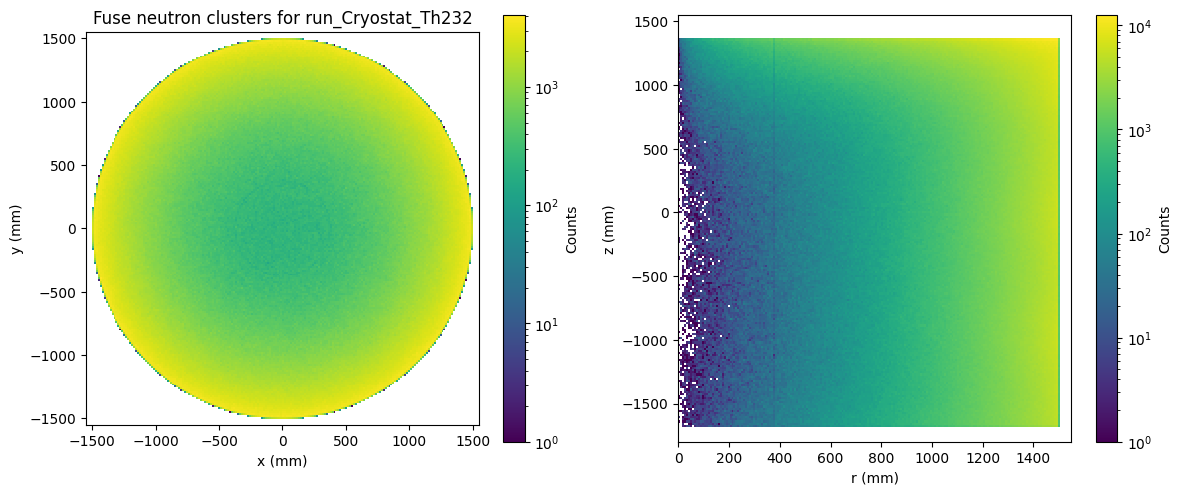

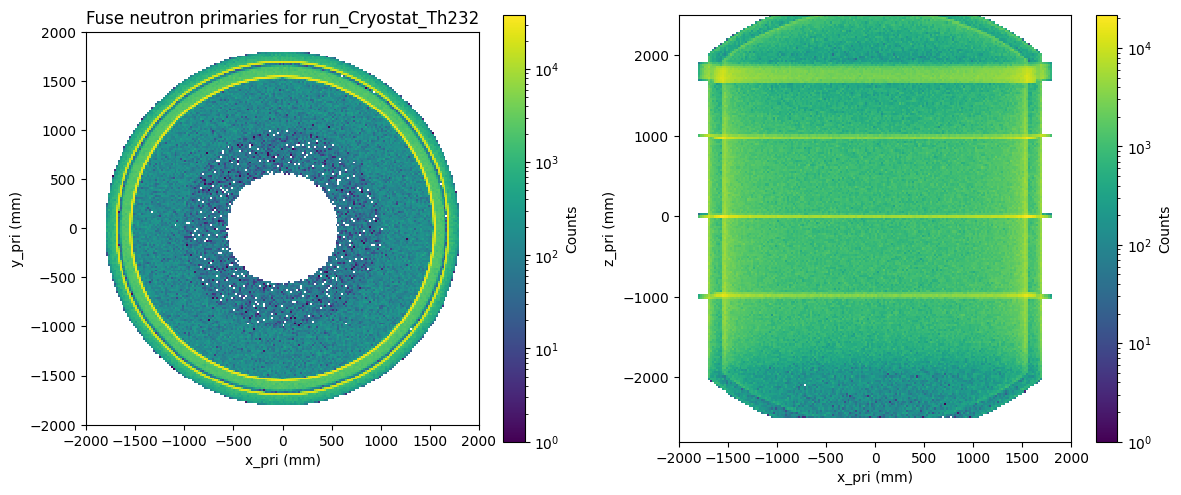

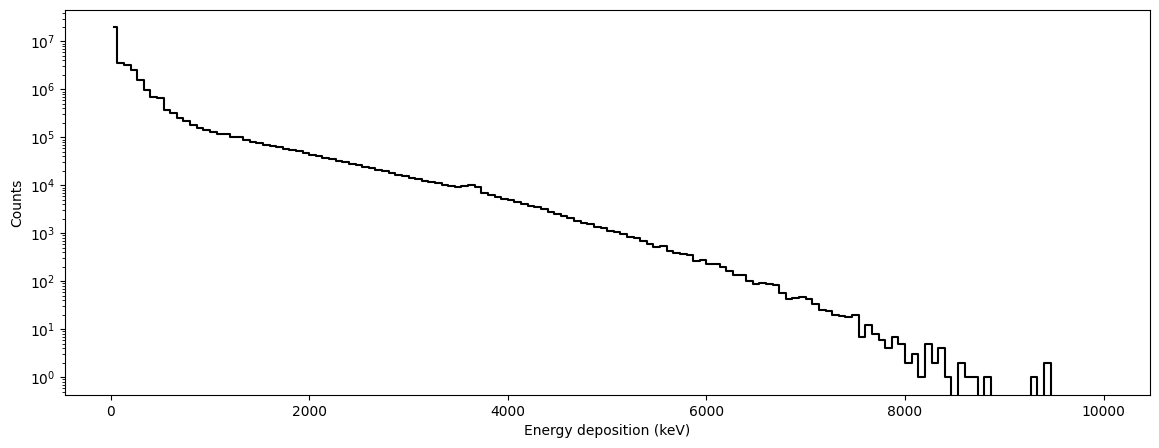

Load run_Teflon_U238


100%|██████████| 72/72 [02:14<00:00,  1.87s/it]


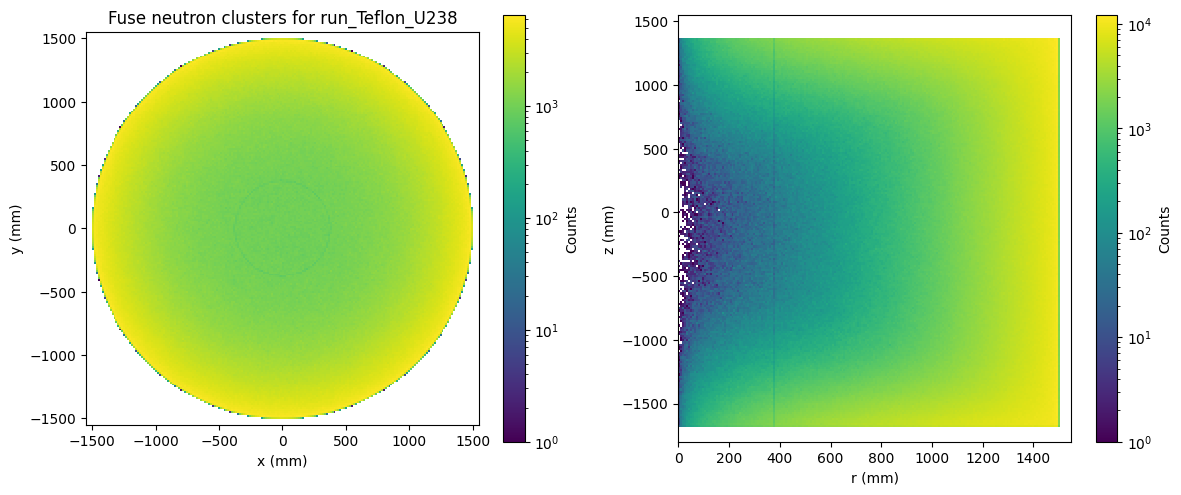

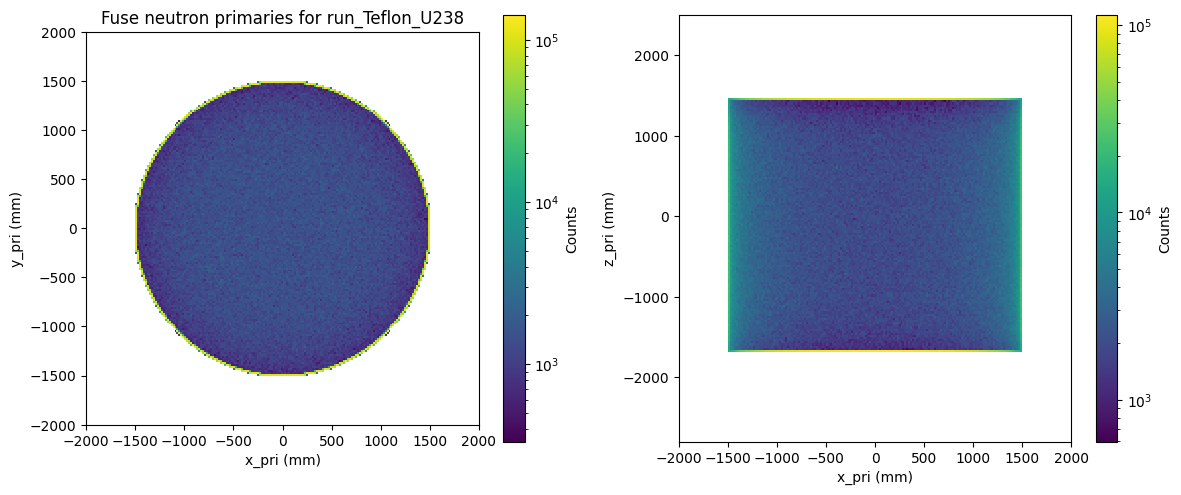

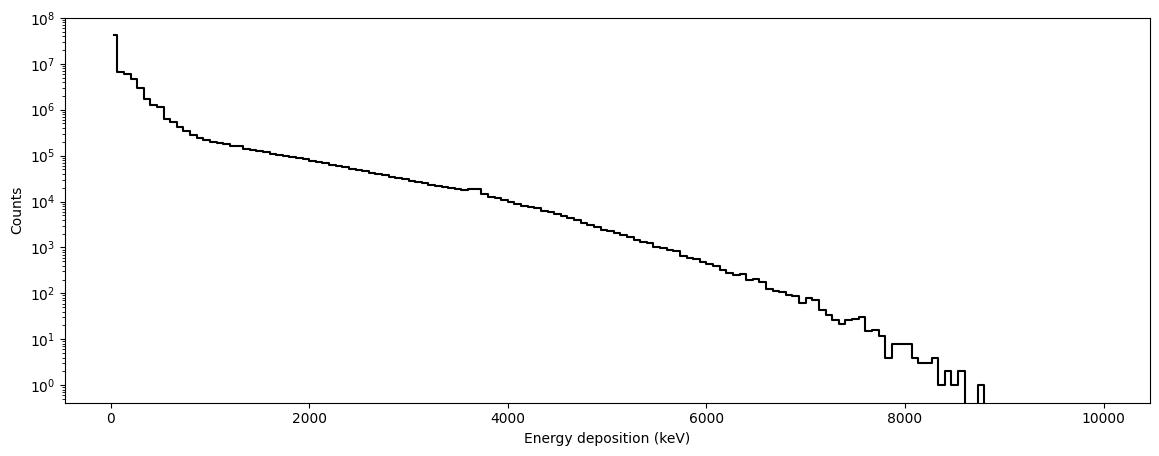

Load run_PMT_U238


100%|██████████| 193/193 [05:45<00:00,  1.79s/it]


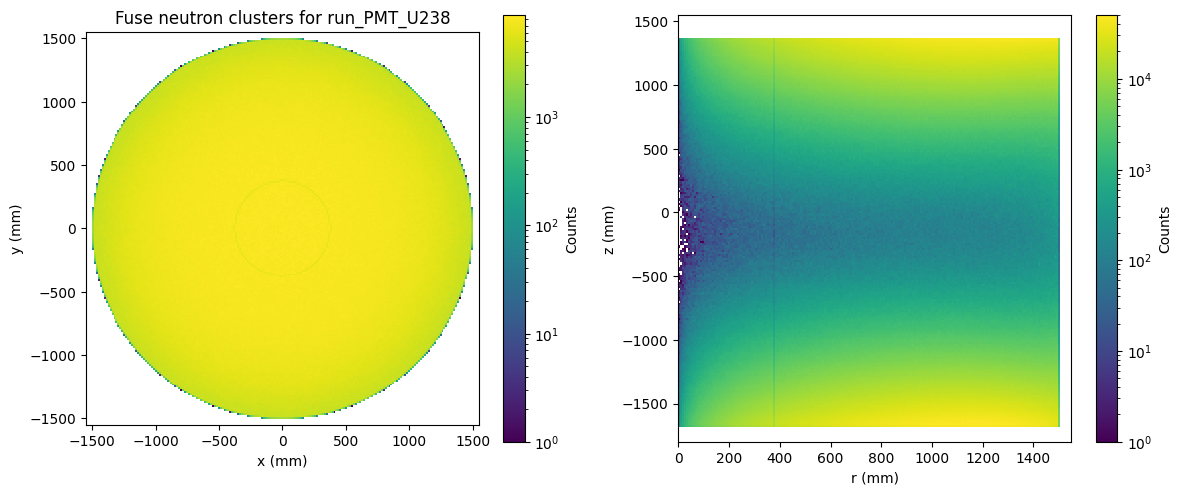

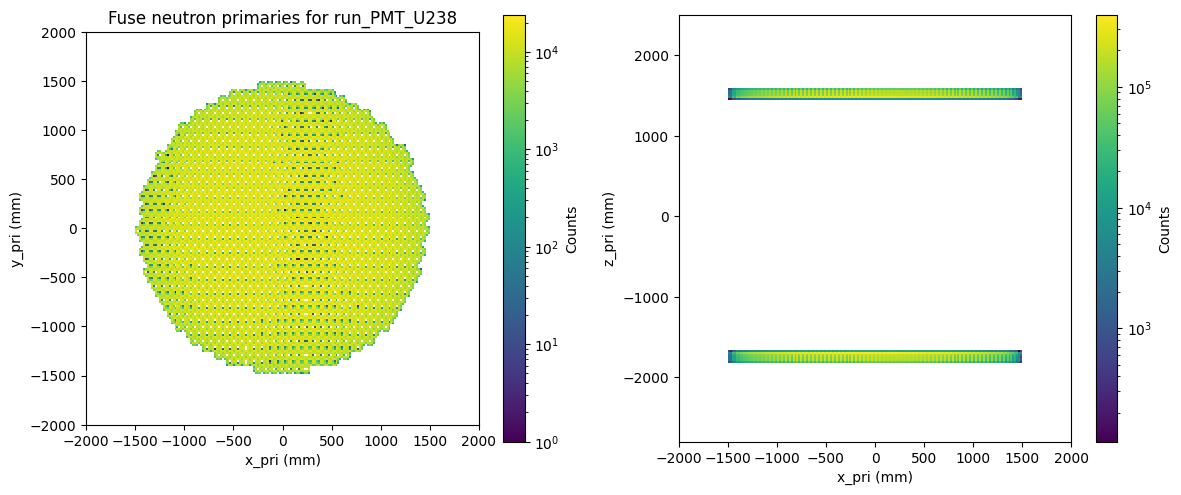

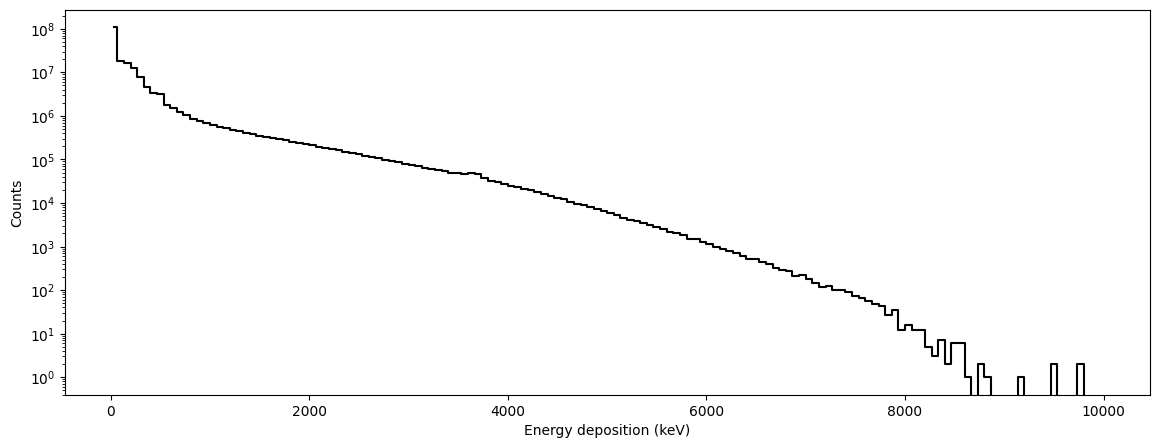

Load run_PMT_Th232


100%|██████████| 66/66 [01:51<00:00,  1.68s/it]


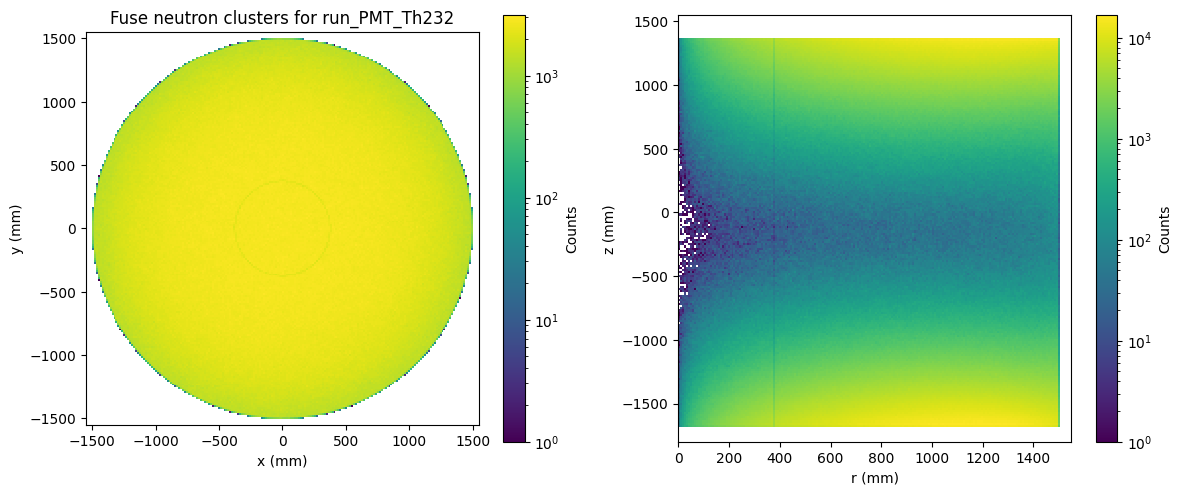

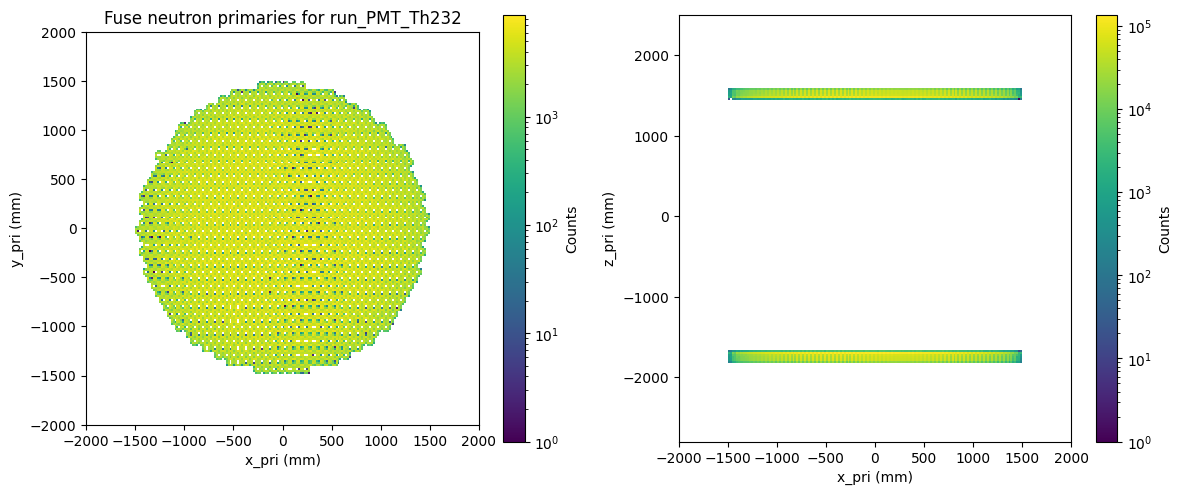

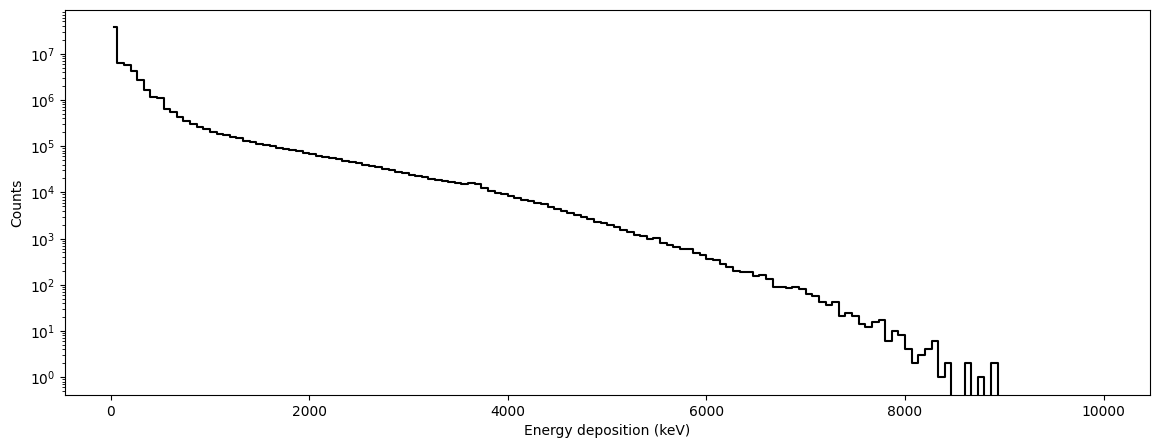

Load run_Sapphire_Th232


100%|██████████| 96/96 [02:56<00:00,  1.84s/it]


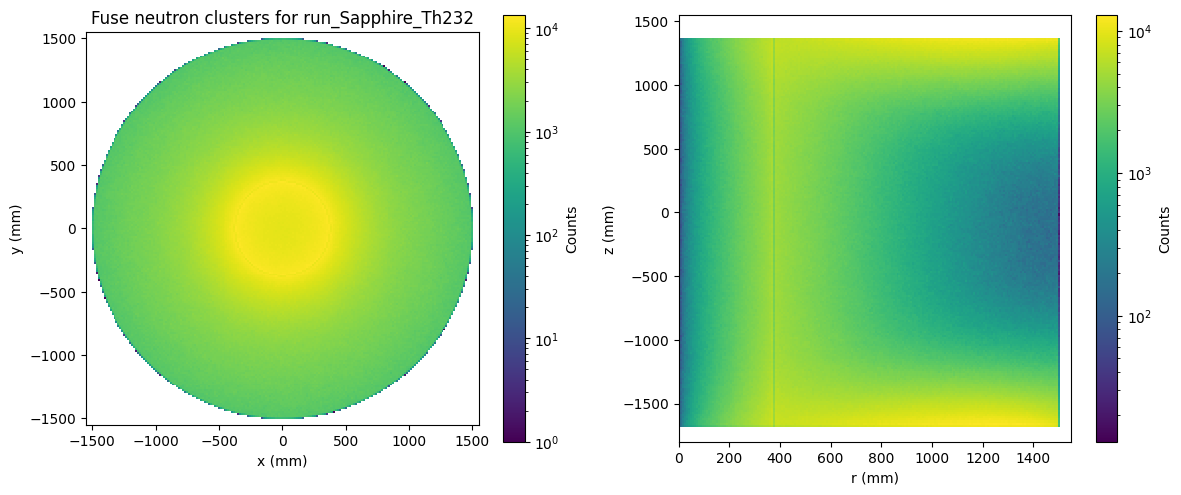

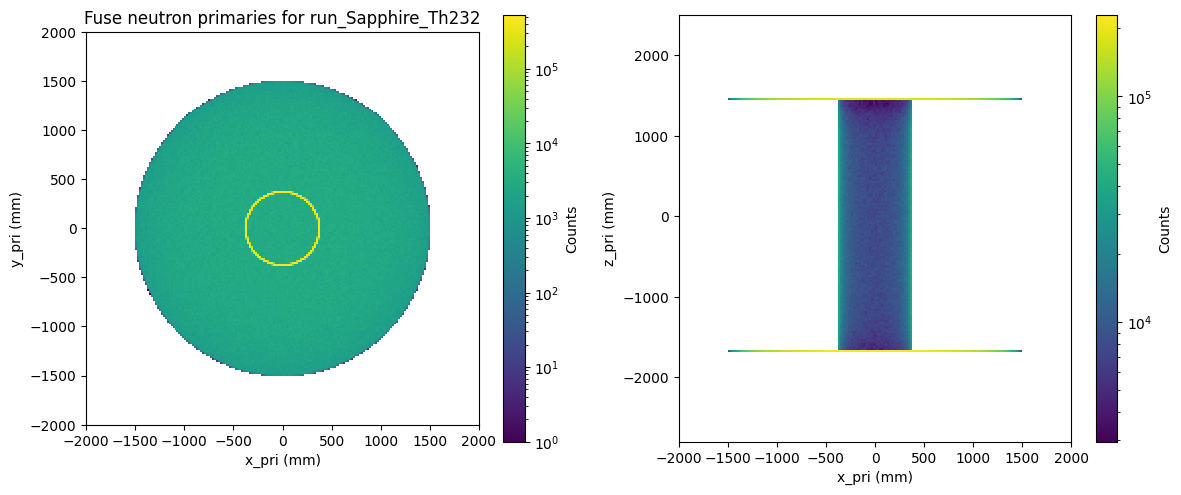

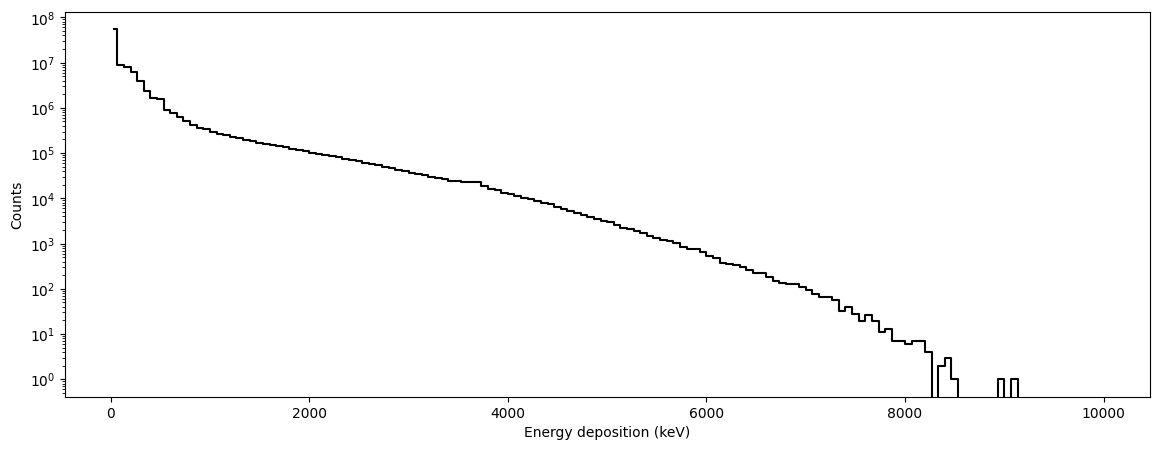

Load run_Copper_Th232


100%|██████████| 75/75 [02:22<00:00,  1.90s/it]


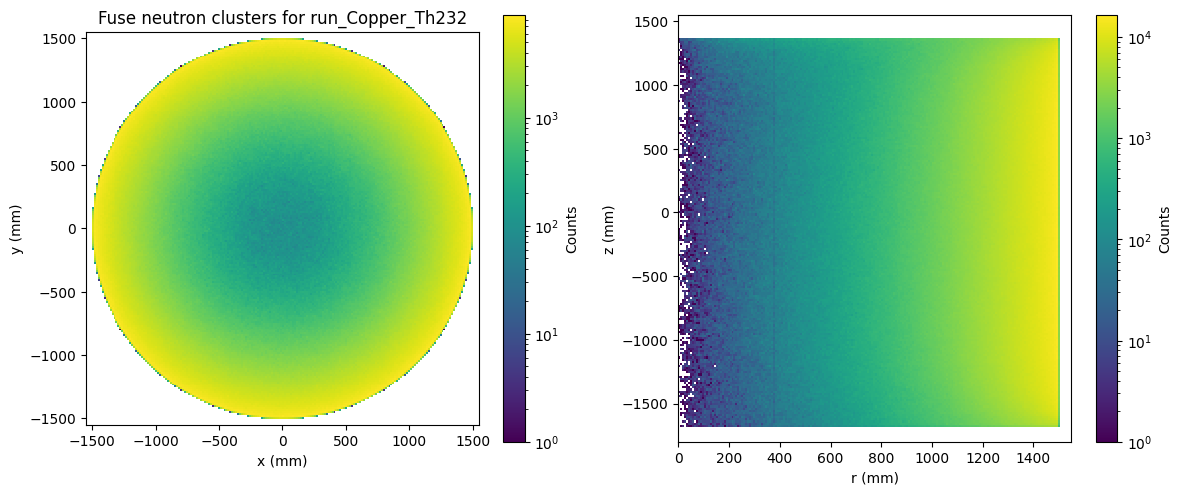

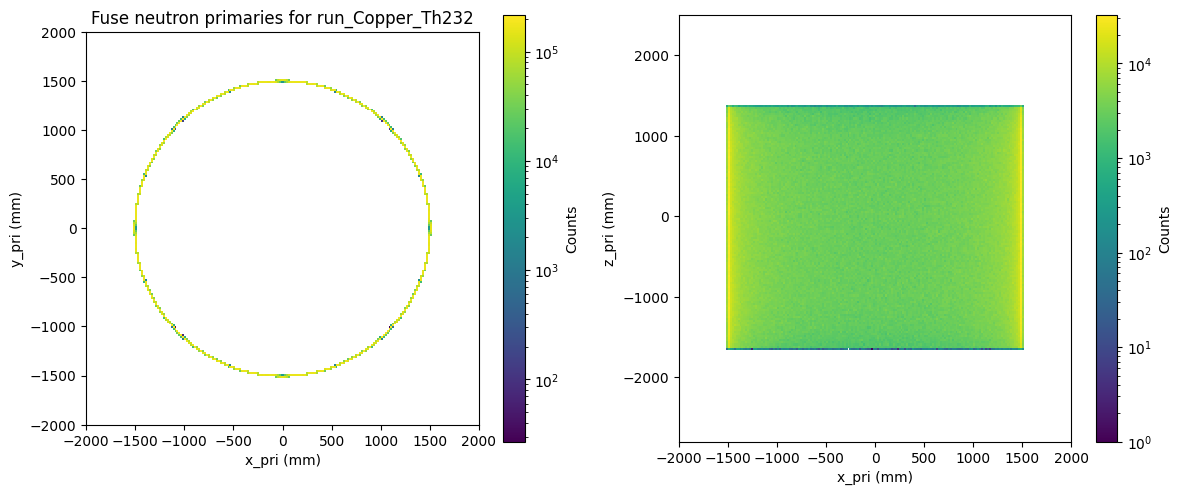

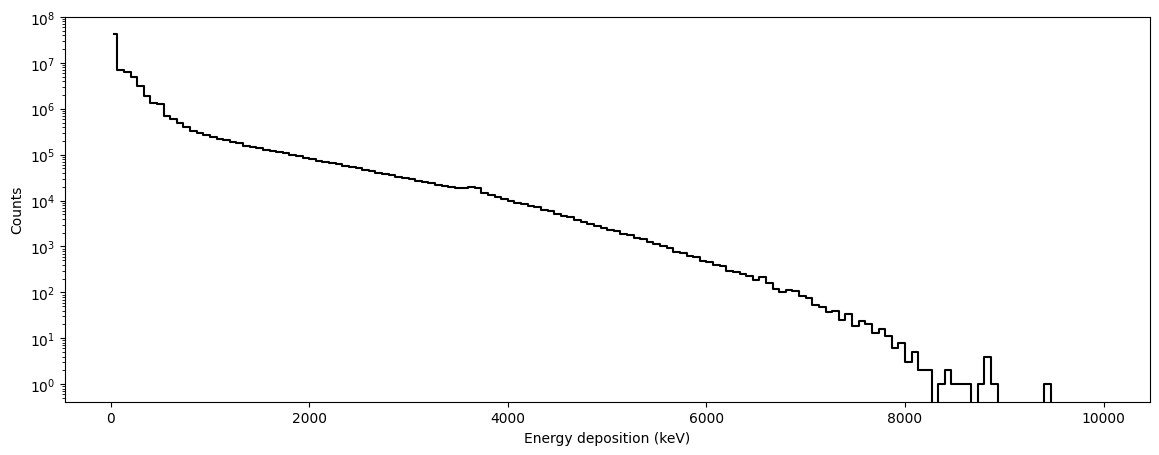

Load run_Copper_U238


100%|██████████| 75/75 [02:14<00:00,  1.80s/it]


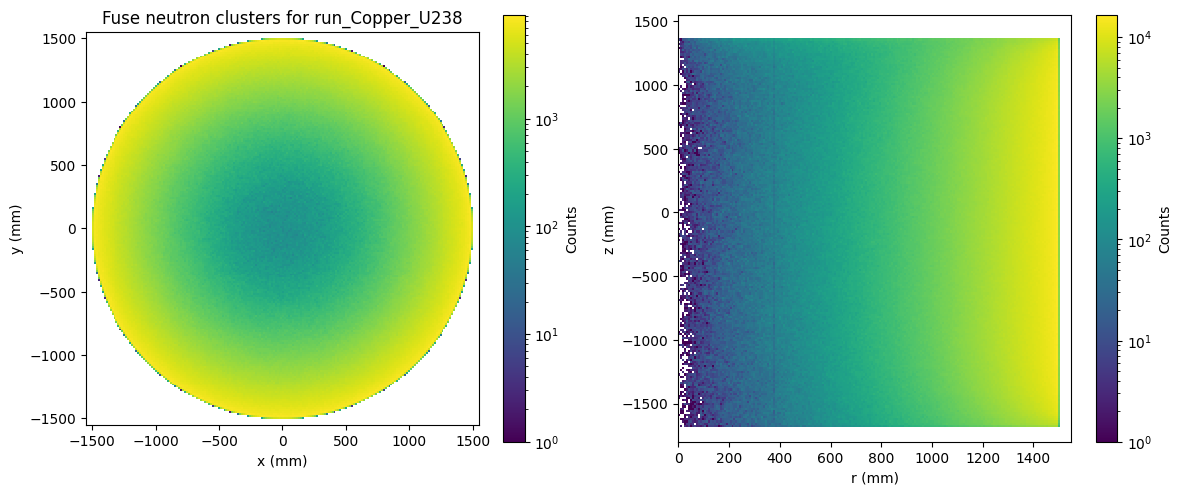

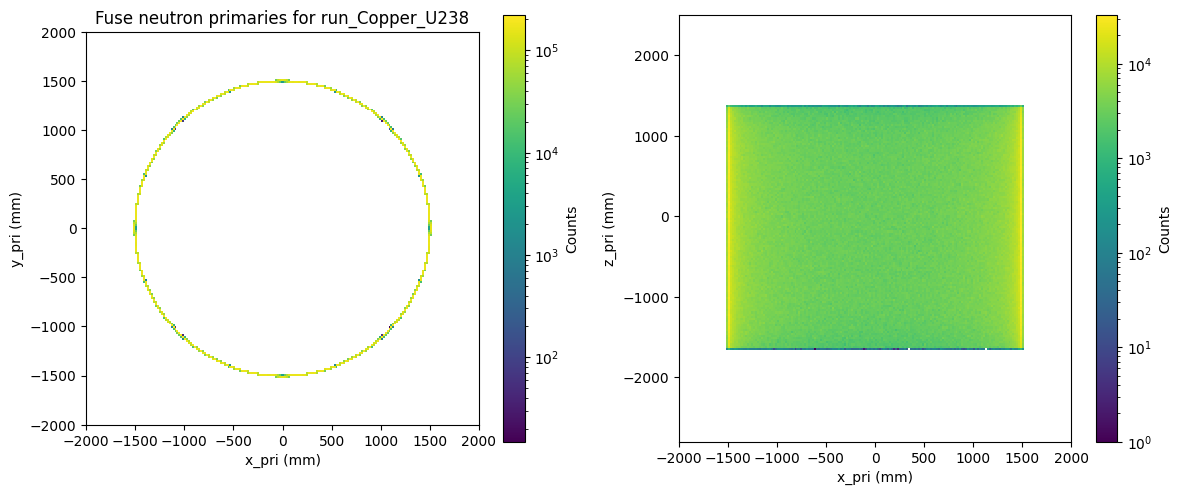

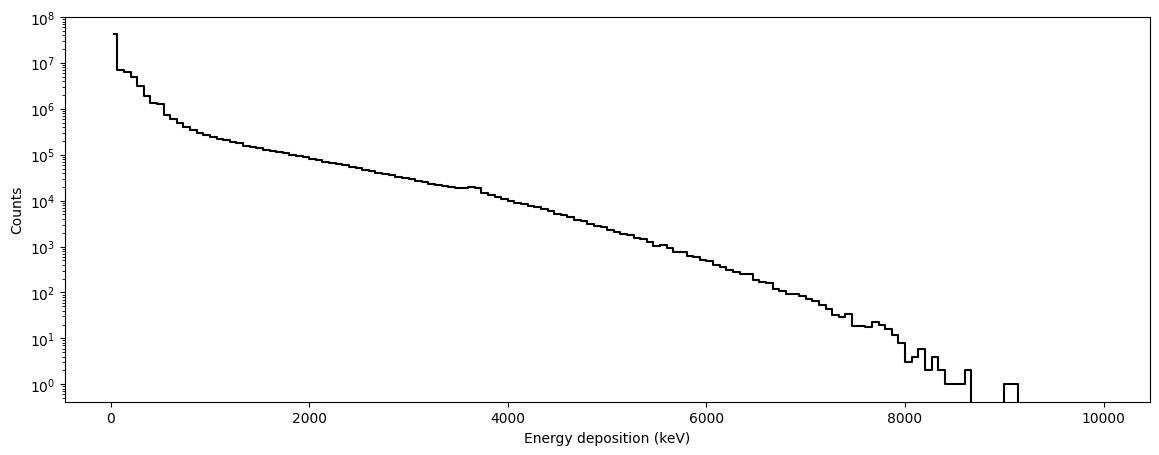

Load run_Cryostat_U238


100%|██████████| 94/94 [03:18<00:00,  2.12s/it]


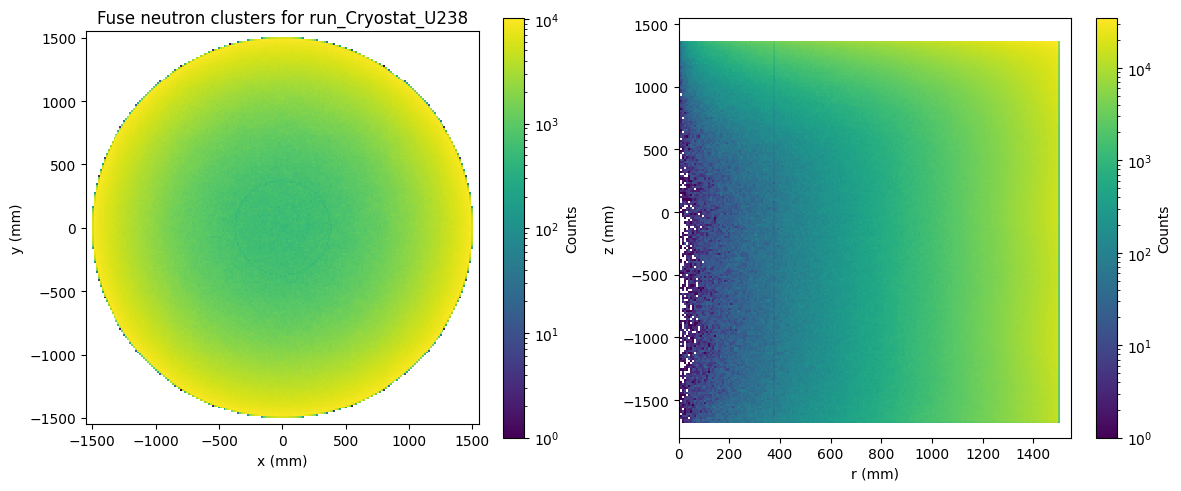

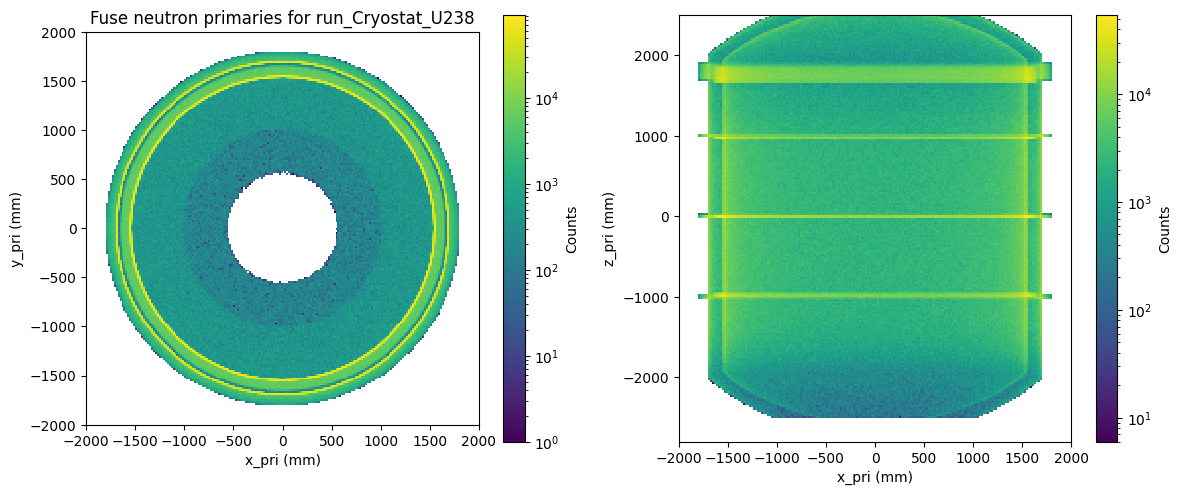

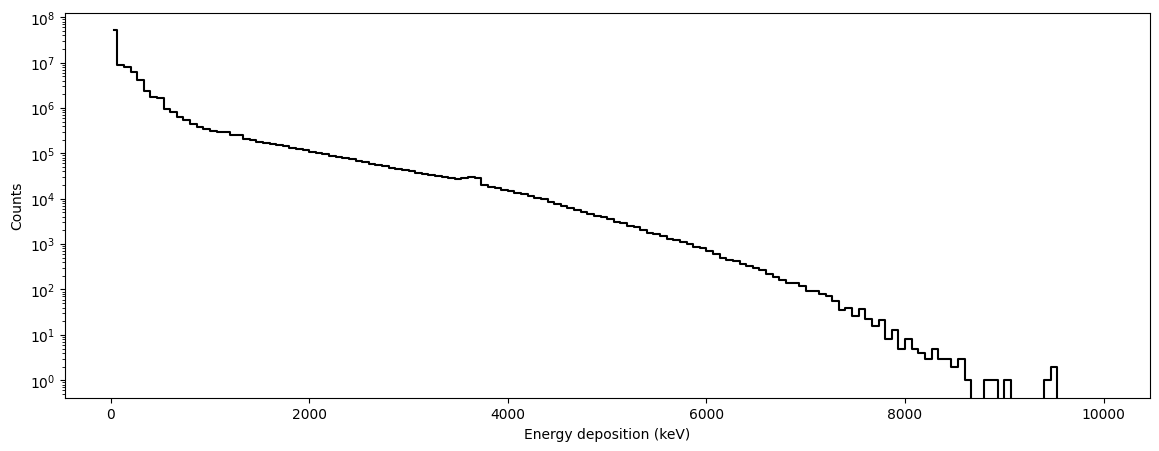

In [7]:
fv_x = 500  # mm
fv_z = (-800, 800)  # mm

for macro, df in dds.items():
    print(f"Load {macro}")
    # Load data in chunks and add to histos
    h_xy = bh.Histogram(bh.axis.Regular(200, -1550, 1550), bh.axis.Regular(200, -1550, 1550))
    h_rz = bh.Histogram(bh.axis.Regular(200, 0, 1550), bh.axis.Regular(200, -1800, 1550))
    h_xy_pri = bh.Histogram(bh.axis.Regular(200, -2000, 2000), bh.axis.Regular(200, -2000, 2000))
    h_xz_pri = bh.Histogram(bh.axis.Regular(200, -2000, 2000), bh.axis.Regular(200, -2800, 2500))
    h_e = bh.Histogram(bh.axis.Regular(150, 0, 10000))

    for chunk in tqdm.tqdm(df.to_delayed()):
        _data = chunk[["x", "y", "z", "ed", "x_pri", "y_pri", "z_pri"]].compute()
        
        h_xy.fill(_data["x"], _data["y"])
        h_rz.fill(np.sqrt(_data["x"]**2 + _data["y"]**2), _data["z"])
        h_xy_pri.fill(_data["x_pri"], _data["y_pri"])
        h_xz_pri.fill(_data["x_pri"], _data["z_pri"])
        h_e.fill(_data["ed"])

    fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12,5))

    hxy = ax1.pcolormesh(*h_xy.axes.edges.T, h_xy.values().T, norm=matplotlib.colors.LogNorm())
    ax1.set_title(f"Fuse neutron clusters for {macro}")
    ax1.set_xlabel("x (mm)")
    ax1.set_ylabel("y (mm)")
    ax1.set_aspect('equal', adjustable='box')

    hyz = ax2.pcolormesh(*h_rz.axes.edges.T, h_rz.values().T, norm=matplotlib.colors.LogNorm())
    #ax2.set_title(f"Fuse Cluster for {key}")
    ax2.set_xlabel("r (mm)")
    ax2.set_ylabel("z (mm)")
    #ax2.set_aspect('equal', adjustable='box')

    # make a box for the fiducial volume
    #ax1.add_patch(plt.Circle((0, 0), fv_x, color='red', fill=False, linestyle='--', linewidth=2, label='Fiducial Volume'))
    #ax2.add_patch(plt.Rectangle((-fv_x, fv_z[0]), 2*fv_x, 2*fv_z[1], color='red', fill=False, linestyle='--', linewidth=2))

    fig.colorbar(hxy, label="Counts")
    fig.colorbar(hyz, label="Counts")
    fig.tight_layout()

    plt.savefig(data_folder+"/fuse_"+macro+"_xy_rz_hist2d.png", dpi=300, bbox_inches='tight')
    plt.show()


    fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12,5))

    hxy = ax1.pcolormesh(*h_xy_pri.axes.edges.T, h_xy_pri.values().T, norm=matplotlib.colors.LogNorm())
    ax1.set_title(f"Fuse neutron primaries for {macro}")
    ax1.set_xlabel("x_pri (mm)")
    ax1.set_ylabel("y_pri (mm)")
    ax1.set_aspect('equal', adjustable='box')

    hyz = ax2.pcolormesh(*h_xz_pri.axes.edges.T, h_xz_pri.values().T, norm=matplotlib.colors.LogNorm())
    #ax2.set_title(f"Fuse Cluster for {macro}")
    ax2.set_xlabel("x_pri (mm)")
    ax2.set_ylabel("z_pri (mm)")
    #ax2.set_aspect('equal', adjustable='box')

    fig.colorbar(hxy, label="Counts")
    fig.colorbar(hyz, label="Counts")
    fig.tight_layout()

    plt.savefig(data_folder+"/fuse_"+macro+"_xy_xz_pri_hist2d.png", dpi=300, bbox_inches='tight')
    plt.show()


    fig = plt.figure(figsize=(14,5))
    #plt.hist(, bins=100, histtype='step', label='All clusters')
    plt.step(h_e.axes[0].centers, h_e.values(), where='mid', label='All clusters', color='black')

    #data_fv = fuse_data[fuse_data["z"].between(*fv_z) & (fuse_data["x"]**2 + fuse_data["y"]**2 <= fv_x**2)]["ed"]
    #plt.hist(data_fv, bins=100, histtype='step', label='FV clusters', color='red')

    #plt.legend()

    plt.xlabel("Energy deposition (keV)")
    plt.ylabel("Counts")
    plt.yscale("log")

    plt.savefig(data_folder+"/fuse_"+macro+"_ed_hist.png", dpi=300, bbox_inches='tight')
    plt.show()

## Volume and mass for each macro

In [8]:
# volume in cm3 and density in g/cm3
volumes = {
    "PMT": None, # PmtTpcTop* -> Top and Bottom PMTs
    "Cryostat": {"volume": 1.5662e+06, "density": 7.7, "confinement": "phys_oCryostat phys_iCryostat"},
    "Teflon": {"volume": 130301, "density": 2.2, "confinement": "phys_GXeTeflonTub phys_LXeTeflonTub"},
    "Copper": {"volume": 56804.8, "density": 8.92, "confinement": "phys_CopperFCTub"},
    "Sapphire": {"volume": 63877.6, "density": 3.98, "confinement": "phys_GXeSapphireTub phys_GXeSapphireCap phys_LXeSapphireTub phys_LXeSapphireCap"},
}

# calculate masses from volume and density
scalings = {}
for k, val in volumes.items():
    if val is not None:
        scalings[k] = val["volume"] * val["density"] / 1000  # convert to kg
scalings["PMT"] = 2 * 1184 # number of PMTs

LXe = {
    "density": 2.862, # g/cm3
    "temperature": 177.05, # K
    "pressure": 1.5 # bar
}

scalings

{'Cryostat': 12059.74,
 'Teflon': 286.6622,
 'Copper': 506.698816,
 'Sapphire': 254.232848,
 'PMT': 2368}

## Materials and their radiopurity

We first collect all our estimates for the materials used in the TPC and their radiopurity levels. We can use the earlier XENONnT and also DARWIN estimates. However, the DARWIN estimates are quite conservative and much higher than what we achieved in XENONnT.

In addition I found some numbers from CRESST for sapphire directly. We could also use the screening results for the ceramic stem of the XENON PMTs but these are expected to be higher since they are made out of ceramix Al2O3 instead of pure sapphire (Al2O3 single crystal).

Further information from XENONnT:
* https://xe1t-wiki.lngs.infn.it/doku.php?id=xenon:xenonnt:ramirez:20171108_xenonnt_radiogenic_nr_bkg_simulations
* https://xe1t-wiki.lngs.infn.it/doku.php?id=xenon:xenonnt_sr0:neutron_background_updated_template
* https://xe1t-wiki.lngs.infn.it/doku.php?id=xenon:xenonnt:analysis:sr0_1_nr_background

In [9]:
neutron_sources = ["U235", "U238", "Th228", "Th232", "Ra226"]

# https://www.sciencedirect.com/science/article/pii/0168900295010955
# SCT and SC are two suppliers of sapphire crystals for CRESST
activity_CRESST = {
    "Sapphire_SCT": {"Unit": "ppb", "U": 0.04, "Th": 0.033, "K": 900,},
    "Sapphire_CS": {"Unit": "ppb", "U": 0.02, "Th": 0.0023, "K": 1800,},
}

# Average and convert ppb to mBq/kg
# 1 mBq/kg 238U = 81 ppt U
# 1 mBq/kg 232Th = 246 ppt Th
# 1 mBq/kg 40K = 32.3 ppb K 
activity_CRESST["Sapphire"] = {"Unit": "mBq/kg"}
for isotope in ["U", "Th", "K"]:
    activity_CRESST["Sapphire"][isotope] = 0.5 * (
        activity_CRESST["Sapphire_SCT"][isotope] + activity_CRESST["Sapphire_CS"][isotope]
    )
activity_CRESST["Sapphire"]["U238"] = activity_CRESST["Sapphire"].pop("U") / 81e-3
activity_CRESST["Sapphire"]["Th232"] = activity_CRESST["Sapphire"].pop("Th") / 246e-3
activity_CRESST["Sapphire"]["K40"] = activity_CRESST["Sapphire"].pop("K") / 32.3

activity_CRESST

{'Sapphire_SCT': {'Unit': 'ppb', 'U': 0.04, 'Th': 0.033, 'K': 900},
 'Sapphire_CS': {'Unit': 'ppb', 'U': 0.02, 'Th': 0.0023, 'K': 1800},
 'Sapphire': {'Unit': 'mBq/kg',
  'U238': 0.37037037037037035,
  'Th232': 0.0717479674796748,
  'K40': 41.795665634674926}}

In [10]:
# Material activity concentrations/levels from DARWIN
# https://arxiv.org/pdf/2003.13407
# Some components have upper limits only, check the paper
activity_DARWIN = {
    "Titanium": {"Unit": "mBq/kg", "U238": 1.6, "Ra226": 0.09, "Th232": 0.28, "Th228": 0.25, "Co60": 0.02, "TI44": 1.16,},
    "PTFE": {"Unit": "mBq/kg", "U238": 1.2, "Ra226": 0.07, "Th232": 0.07, "Th228": 0.06, "Co60": 0.027,},
    "Copper": {"Unit": "mBq/kg", "U238": 1.0, "Ra226": 0.035, "Th232": 0.033, "Th228": 0.026, "Co60": 0.019,},
    "PMT": {"Unit": "mBq/unit", "U238": 8.0, "Ra226": 0.6, "Th232": 0.7, "Th228": 0.6, "Co60": 0.84,},
    "Electronics": {"Unit": "mBq/unit", "U238": 1.10, "Ra226": 0.34, "Th232": 0.16, "Th228": 0.16, "Co60": 0.008,},
}

# Material activity concentrations/levels from XENONnT
# In addition to DARWIN materials to include Cirlex, Quartz, Kovar, Steel, Al2O3
activity_XENONnT = {
    "PMT_Stem": {"Material": "Al2O3", "Unit": "mBq/unit", "U235": 0.28, "U238": 1.37, "Th228": 0.5, "Th232": 0.17, "Ra226": 0.26,},
    "PMT_Base": {"Material": "cirlex", "Unit": "mBq/unit", "U235": 0.18, "U238": 0.47, "Th228": 0.45, "Th232": 0.15, "Ra226": 0.32,},
    "PMT_Window": {"Material": "quartz", "Unit": "mBq/unit", "U235": 0.06, "U238": 0.69, "Th228": 0.06, "Th232": 0.02, "Ra226": 0.07,},
    "PMT_Body": {"Material": "kovar", "Unit": "mBq/unit", "U235": 0.02, "U238": 0.08, "Th228": 0.81, "Th232": 0.04, "Ra226": 0.31,},
    "PMT_Shell": {"Material": "steel", "Unit": "mBq/unit", "U235": 0.03, "U238": 0.15, "Th228": 0.11, "Th232": 0.03, "Ra226": 0.07,},
    "TPC_Walls": {"Material": "PTFE", "Unit": "mBq/kg", "U235": 0.07, "U238": 0.13, "Th228": 0.06, "Th232": 0.05, "Ra226": 0.14,},
    "InnerCryostat_Shell": {"Material": "steel", "Unit": "mBq/kg", "U235": 2.6, "U238": 8.81, "Th228": 1.27, "Th232": 1.15, "Ra226": 3.10,},
    "OuterCryostat_Shell": {"Material": "steel", "Unit": "mBq/kg", "U235": 2.19, "U238": 16.34, "Th228": 0.83, "Th232": 1.77, "Ra226": 2.70,},
}

# Calculate Cryostat as average of Inner and Outer Cryostat
activity_XENONnT["Cryostat"] = {}
for isotope in neutron_sources:
    activity_XENONnT["Cryostat"][isotope] = 0.5 * (
        activity_XENONnT["InnerCryostat_Shell"][isotope] + activity_XENONnT["OuterCryostat_Shell"][isotope]
    )

activity = {
    "PMT": activity_DARWIN["PMT"],
    "Cryostat": activity_XENONnT["Cryostat"],
    "Teflon": activity_XENONnT["TPC_Walls"],
    "Copper": activity_DARWIN["Copper"],
    "Sapphire": activity_XENONnT["PMT_Stem"],
}

activity

{'PMT': {'Unit': 'mBq/unit',
  'U238': 8.0,
  'Ra226': 0.6,
  'Th232': 0.7,
  'Th228': 0.6,
  'Co60': 0.84},
 'Cryostat': {'U235': 2.395,
  'U238': 12.575,
  'Th228': 1.05,
  'Th232': 1.46,
  'Ra226': 2.9000000000000004},
 'Teflon': {'Material': 'PTFE',
  'Unit': 'mBq/kg',
  'U235': 0.07,
  'U238': 0.13,
  'Th228': 0.06,
  'Th232': 0.05,
  'Ra226': 0.14},
 'Copper': {'Unit': 'mBq/kg',
  'U238': 1.0,
  'Ra226': 0.035,
  'Th232': 0.033,
  'Th228': 0.026,
  'Co60': 0.019},
 'Sapphire': {'Material': 'Al2O3',
  'Unit': 'mBq/unit',
  'U235': 0.28,
  'U238': 1.37,
  'Th228': 0.5,
  'Th232': 0.17,
  'Ra226': 0.26}}

## Calculation of the neutron production rates - neutron yields

The method to derive the neutron production rates for each material is based on the SOURCES-4A code, which takes takes into account (α,n) and spontaneous fission reactions. This is the same method as used in XENONnT such that I quote here their relevant numbers.

As quoted by the developers, SOURCES-4A has a systematic uncertainty of 17 %, much higher than the statistical uncertainty (107 neutrons generated from each component). This means that in the following values are quoted without error, assuming that the uncertainty of the final results is also of 17 %.

In [11]:
# Neutron yield, [neutrons/decay]
# from https://xe1t-wiki.lngs.infn.it/doku.php?id=xenon:xenonnt_sr0:neutron_background_updated_template
# from https://github.com/XENONnT/nton/blob/neutron_sim/nton/background/neutron_background/neutron_prediction.py
# Main source: https://arxiv.org/pdf/1512.07501
nyield = {
    "Al2O3": {"U238": 1.2e-6, "U235": 1.3e-5, "Ra226": 6.0e-6, "Th232": 9.2e-9, "Th228": 1.4e-5,},
    "cirlex": {"U238": 1.3e-6, "U235": 2.2e-6, "Ra226": 3.5e-6, "Th232": 4.1e-8, "Th228": 2.4e-6,},
    "quartz": {"U238": 1.2e-6, "U235": 1.9e-6, "Ra226": 8.8e-7, "Th232": 6.8e-9, "Th228": 1.9e-6,},
    "kovar": {"U238": 1.1e-6, "U235": 1.3e-7, "Ra226": 1.2e-7, "Th232": 3.0e-11, "Th228": 1.0e-6,},
    "steel": {"U238": 1.1e-6, "U235": 4.1e-7, "Ra226": 3.1e-7, "Th232": 1.8e-9, "Th228": 2.0e-6,},
    "PTFE": {"U238": 7.4e-6, "U235": 1.3e-4, "Ra226": 5.5e-5, "Th232": 7.3e-7, "Th228": 1.0e-4,},
    "copper": {"U238": 1.1e-6, "U235": 3.3e-8, "Ra226": 2.5e-8, "Th232": 3.0e-11, "Th228": 3.6e-7,},
}

# function to map material names between our simulation and the neutron yield dictionary
def map_material_name(sim_material):
    mapping = {
        "PMT": "quartz",
        "Cryostat": "steel",
        "Teflon": "PTFE",
        "Copper": "copper",
        "Sapphire": "Al2O3",
    }
    return mapping.get(sim_material, None)

In [12]:
TPC_dimensions = {
    "radius": 1500, # mm
    "top": 1365, # mm
    "bottom": -1682, # mm
}
TPC_center = [0, 0, TPC_dimensions["top"]-(TPC_dimensions["top"] - TPC_dimensions["bottom"]) / 2]

# Define a fiducial volume with fixed mass by giving a certain radius and adjusting the z boundaries
fv_radius = 1250 # mm
fv_mass = 34.0e3 # kg

fv_volume_cm3 = fv_mass * 1000 / LXe["density"] # cm3
fv_height_mm = fv_volume_cm3 / (np.pi * (fv_radius/10)**2) * 10 # mm
fv_z = [TPC_center[2] - fv_height_mm/2, TPC_center[2] + fv_height_mm/2]

if fv_z[0] < TPC_dimensions["bottom"] or fv_z[1] > TPC_dimensions["top"]:
    print("Warning: Fiducial volume z boundaries exceed TPC dimensions!")

print(f"TPC center z position: {TPC_center[2]} mm")
print(f"Fiducial volume height for {fv_mass} kg at radius {fv_radius} mm: {fv_height_mm:.2f} mm")
print(f"Fiducial volume z boundaries for {fv_mass} kg at radius {fv_radius} mm: [{fv_z[0]:.2f}, {fv_z[1]:.2f}] mm")

TPC center z position: -158.5 mm
Fiducial volume height for 34000.0 kg at radius 1250 mm: 2420.13 mm
Fiducial volume z boundaries for 34000.0 kg at radius 1250 mm: [-1368.57, 1051.57] mm


In [13]:
def select_events_in_energy_range(df, energy_range=(4, 50)):
    # energy ROI cut
    # NR: (4, 50) keV -> ER: (1, 12) keV
    return df.query(f"ed >= {energy_range[0]} and ed <= {energy_range[1]}")

# and occur inside the fiducial volume and within the energy ROI
def select_events_in_roi(df, fv_z, fv_radius, energy_range=(4, 50)):
    events_roi = df.query(f"ed >= {energy_range[0]} and ed <= {energy_range[1]} and "
                          f"z >= {fv_z[0]} and z <= {fv_z[1]} and "
                          f"x**2 + y**2 <= {fv_radius}**2")
    return events_roi

In [10]:
# Read estimates from file
with open(data_folder+'/neutron_background_estimates.pkl', 'rb') as f:
    estimates = pickle.load(f)

In [20]:
_dds = dds
#_dds = {key: df for key,df in dds.items() if "Cryostat_U238" in key or "PMT_U238" in key}

estimates = {}
for key, df in tqdm.tqdm(_dds.items()):
    material = key.split("_")[1]
    isotope = key.split("_")[2]

    columns = ["x", "y", "z", "ed", "n_clusters"]

    # We select the events that mimic a WIMP signal with a single elastic scatter in the whole active volume
    df_ss = df[df['n_clusters'] == 1][columns].compute()

    df_ss_energy = select_events_in_energy_range(df_ss, energy_range=(4, 50))
    df_ss_roi = select_events_in_roi(df_ss, fv_z, fv_radius, energy_range=(4, 50))

    # get number of neutrons per key
    # infer from the unique runids and assume 5000 neutrons per runid
    n_neutrons = len(df["runid"].unique()) * 5000

    # get number of total decays
    n_decays = n_neutrons / nyield[map_material_name(material)][isotope]

    # get estimate of neutron per year
    simulated_exposure = n_decays / (activity[material][isotope]*scalings[material]) /(60*60*24*365) # in years

    # get number of single scatter events total and in ROI
    n_ss_events = len(df_ss)
    #n_ss_energy_events = len(df_ss_energy)
    n_ss_roi_events = len(df_ss_roi)

    # Store histograms
    r_max = 1600
    h_xy_ss = bh.Histogram(bh.axis.Regular(200, -r_max, r_max), bh.axis.Regular(200, -r_max, r_max))
    h_xy_ss_energy = bh.Histogram(bh.axis.Regular(200, -r_max, r_max), bh.axis.Regular(200, -r_max, r_max))
    h_xy_ss_roi = bh.Histogram(bh.axis.Regular(200, -r_max, r_max), bh.axis.Regular(200, -r_max, r_max))
    h_rz_ss = bh.Histogram(bh.axis.Regular(200, 0, r_max), bh.axis.Regular(200, -1800, 1500))
    h_rz_ss_energy = bh.Histogram(bh.axis.Regular(200, 0, r_max), bh.axis.Regular(200, -1800, 1500))
    h_rz_ss_roi = bh.Histogram(bh.axis.Regular(200, 0, r_max), bh.axis.Regular(200, -1800, 1500))

    h_xy_ss.fill(df_ss["x"], df_ss["y"])
    h_rz_ss.fill(np.sqrt(df_ss["x"]**2 + df_ss["y"]**2), df_ss["z"])

    h_xy_ss_energy.fill(df_ss_energy["x"], df_ss_energy["y"])
    h_rz_ss_energy.fill(np.sqrt(df_ss_energy["x"]**2 + df_ss_energy["y"]**2), df_ss_energy["z"])

    h_xy_ss_roi.fill(df_ss_roi["x"], df_ss_roi["y"])
    h_rz_ss_roi.fill(np.sqrt(df_ss_roi["x"]**2 + df_ss_roi["y"]**2), df_ss_roi["z"])

    _estimates = {isotope: {
        "n_neutrons": n_neutrons,
        "n_decays": n_decays,
        "simulated_exposure_years": simulated_exposure,
        "df_ss_energy": df_ss_energy,
        "n_ss_events": n_ss_events,
        #"n_ss_energy_events": n_ss_energy_events,
        "n_ss_roi_events": n_ss_roi_events,
        "h_xy_ss": h_xy_ss,
        "h_xy_ss_energy": h_xy_ss_energy,
        "h_xy_ss_roi": h_xy_ss_roi,
        "h_rz_ss": h_rz_ss,
        "h_rz_ss_energy": h_rz_ss_energy,
        "h_rz_ss_roi": h_rz_ss_roi,
    }}

    if material not in estimates:
        estimates[material] = {}
    estimates[material].update(_estimates)

# Store estimates to file
with open(data_folder+'/neutron_background_estimates.pkl', 'wb') as f:
    pickle.dump(estimates, f)

100%|██████████| 10/10 [33:11<00:00, 199.11s/it]


In [21]:
total_event_rate = 0.0

for material, mat_data in estimates.items():
    for isotope, iso_data in mat_data.items():
        event_rate = iso_data['n_ss_roi_events']/iso_data['simulated_exposure_years']/(fv_mass/1e3)
        total_event_rate += event_rate

        print(f"Material: {material}, Isotope: {isotope}")
        print(f"  Number of neutrons simulated: {iso_data['n_neutrons']}")
        print(f"  Number of decays simulated: {iso_data['n_decays']:.2e}")
        print(f"  Simulated exposure: {iso_data['simulated_exposure_years']:.2f} years")
        print(f"  Total single scatter events: {iso_data['n_ss_events']}")
        print(f"  -> in fiducial volume and energy ROI: {iso_data['n_ss_roi_events']}")
        print(f"  -> as event rate [events/tonne/year]: {event_rate:.4f}")
        print()

print(f"Total neutron background event rate in fiducial volume and energy ROI: {total_event_rate:.4f} events/tonne/year")

Material: Sapphire, Isotope: U238
  Number of neutrons simulated: 3445000
  Number of decays simulated: 2.87e+12
  Simulated exposure: 261.37 years
  Total single scatter events: 103641
  -> in fiducial volume and energy ROI: 142
  -> as event rate [events/tonne/year]: 0.0160

Material: Sapphire, Isotope: Th232
  Number of neutrons simulated: 3445000
  Number of decays simulated: 3.74e+14
  Simulated exposure: 274735.14 years
  Total single scatter events: 107843
  -> in fiducial volume and energy ROI: 96
  -> as event rate [events/tonne/year]: 0.0000

Material: Teflon, Isotope: Th232
  Number of neutrons simulated: 3675000
  Number of decays simulated: 5.03e+12
  Simulated exposure: 11137.49 years
  Total single scatter events: 154708
  -> in fiducial volume and energy ROI: 45
  -> as event rate [events/tonne/year]: 0.0001

Material: Teflon, Isotope: U238
  Number of neutrons simulated: 3675000
  Number of decays simulated: 4.97e+11
  Simulated exposure: 422.58 years
  Total single sc

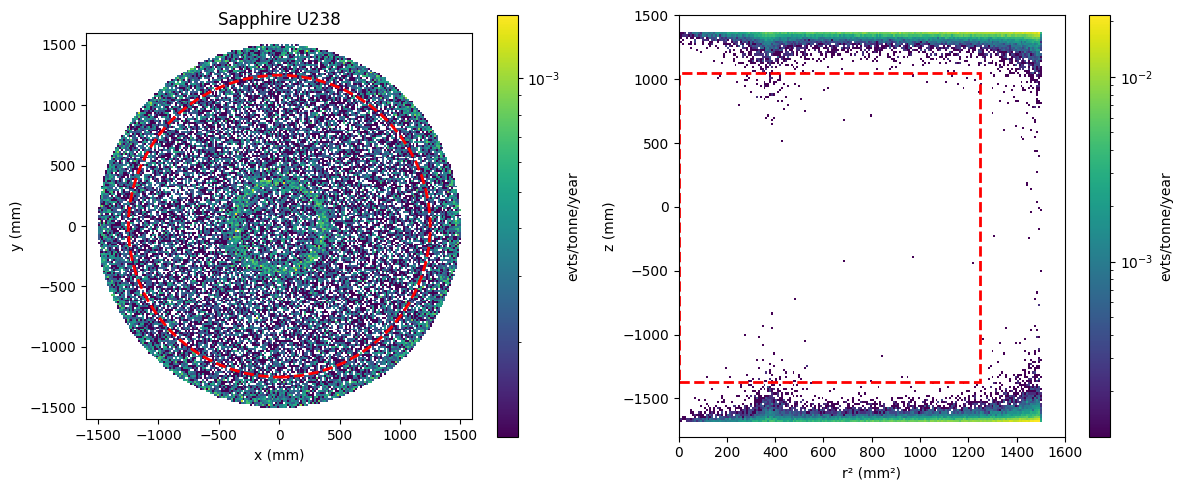

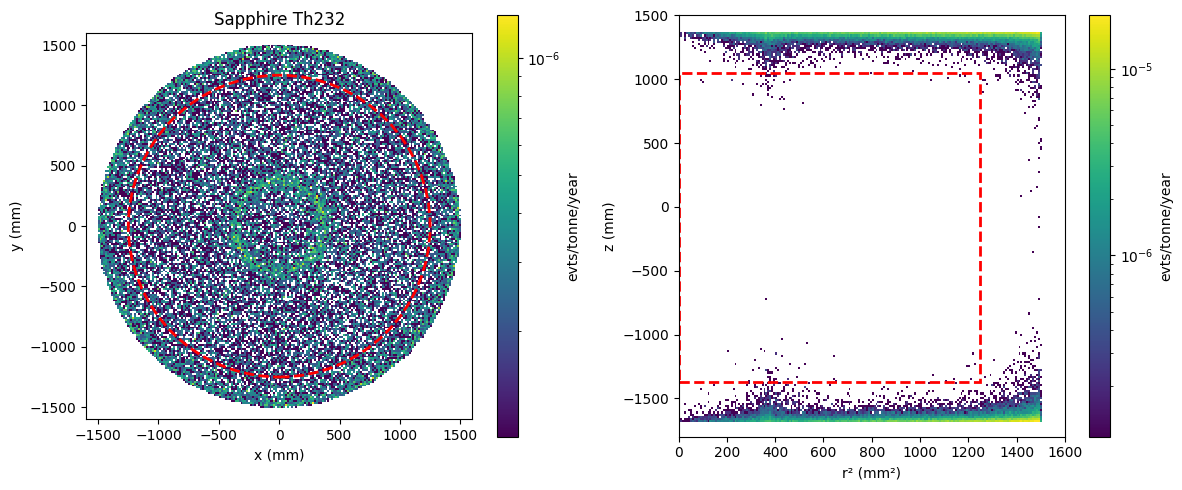

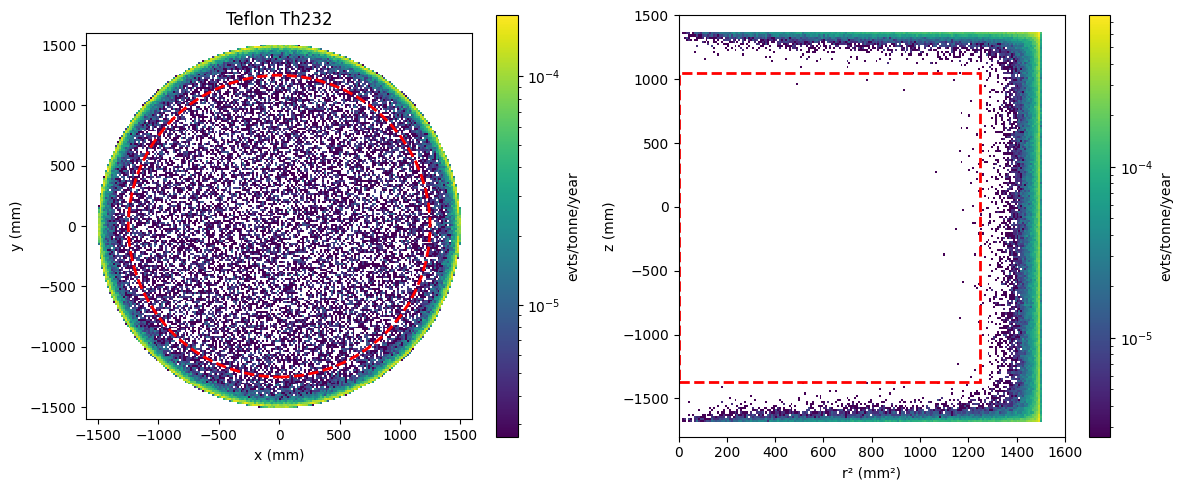

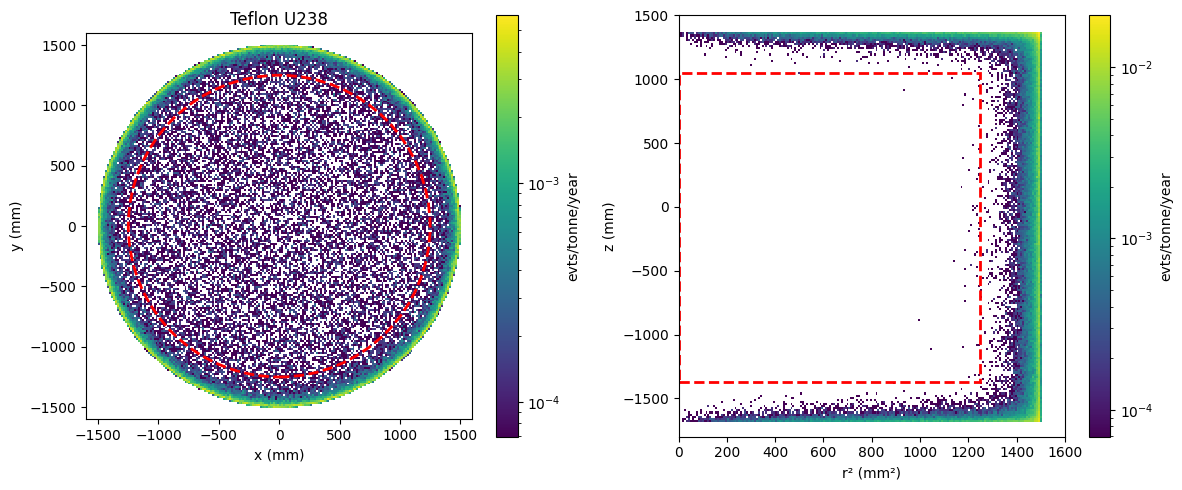

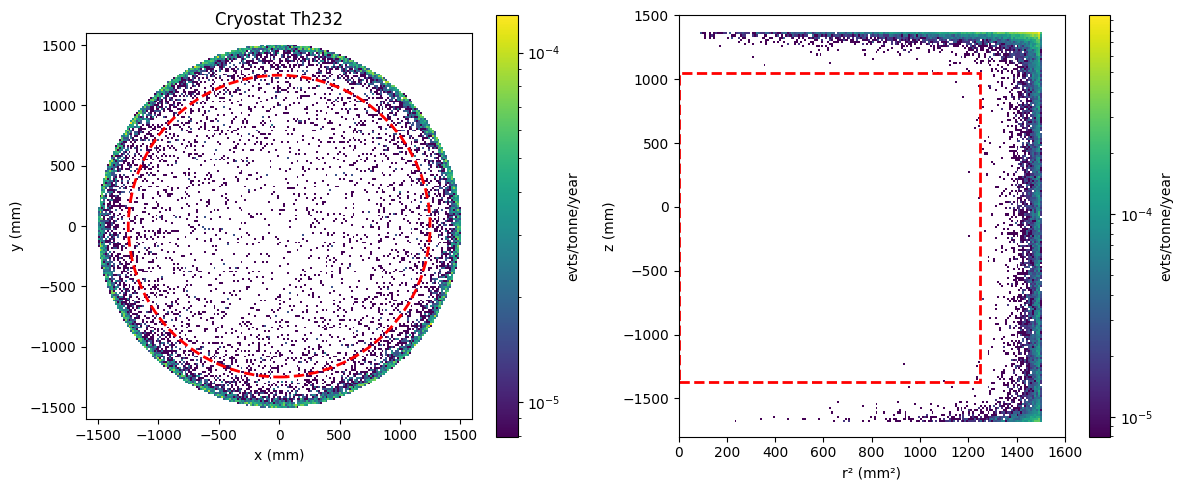

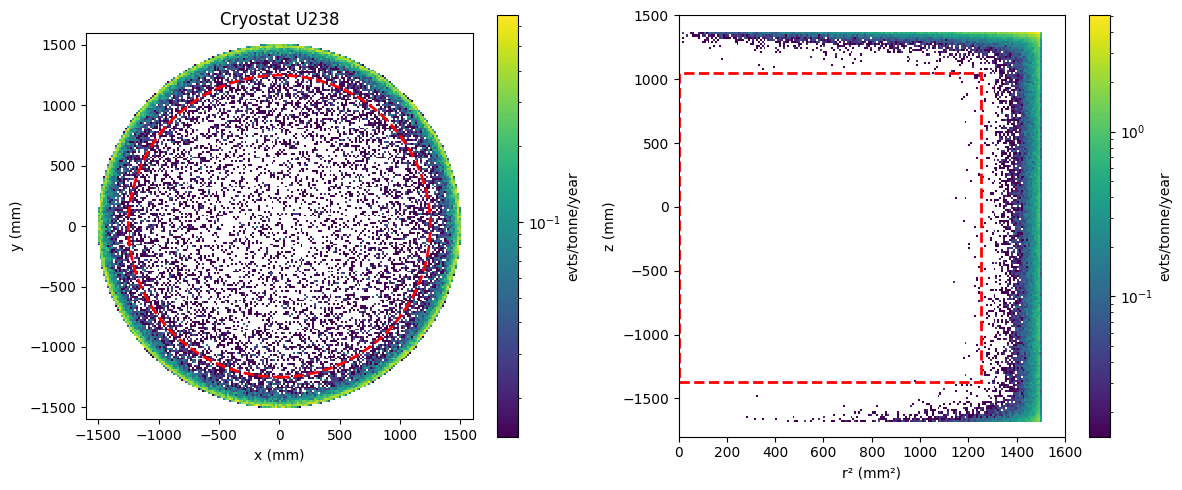

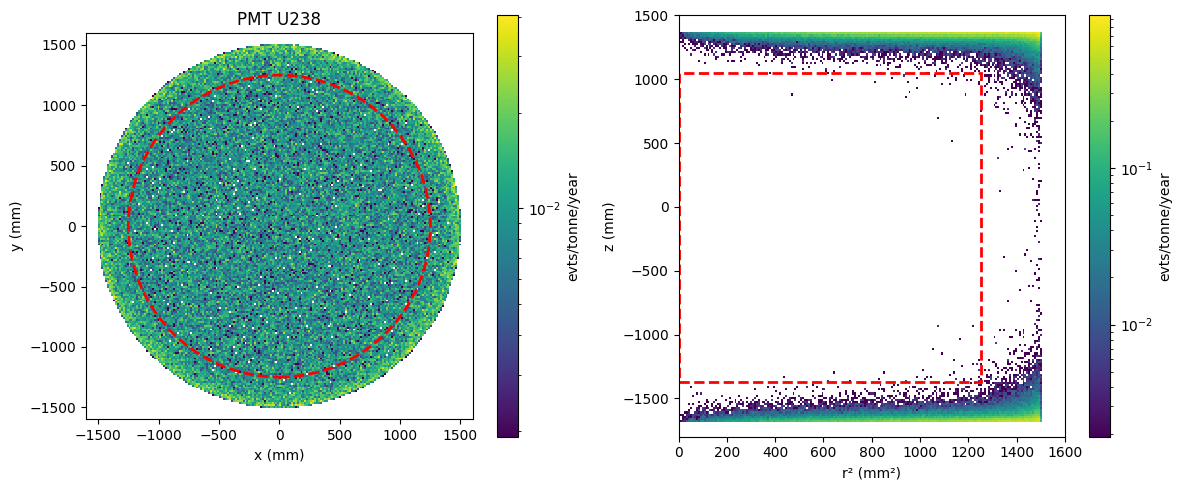

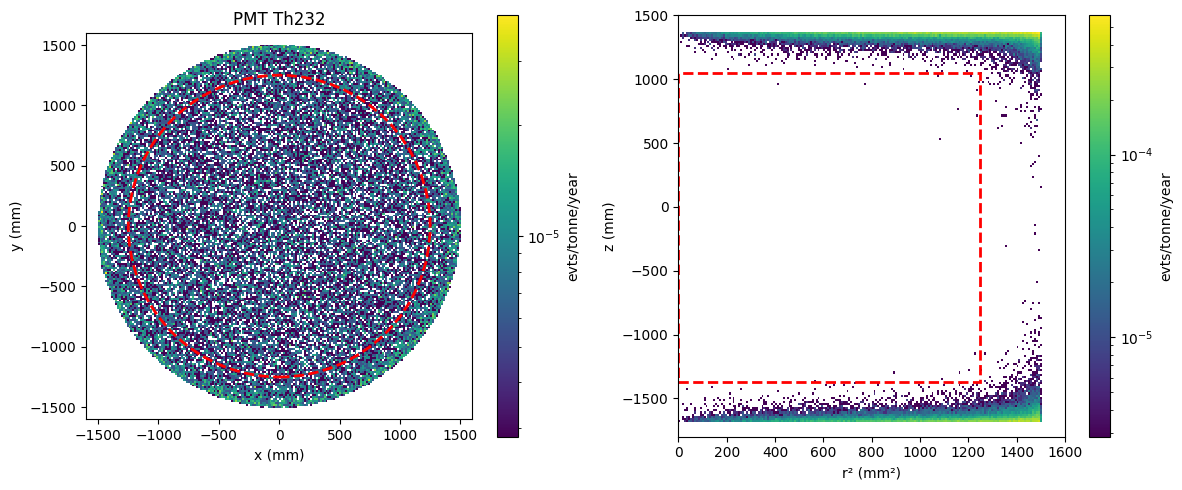

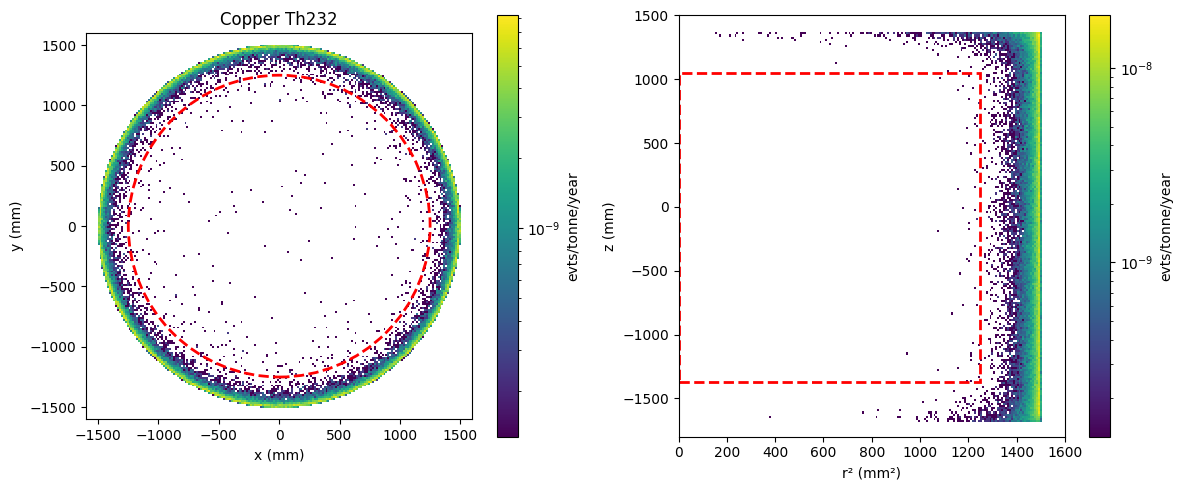

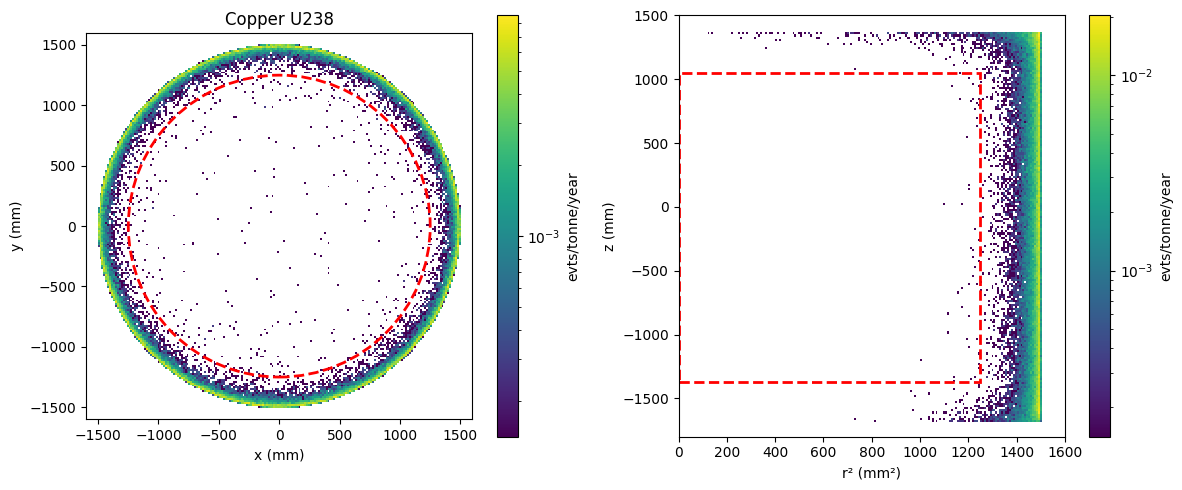

In [22]:
for material, mat_data in estimates.items():
    for isotope, iso_data in mat_data.items():
        fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12,5))
        tag = "_ss_energy"

        pcm1 = ax1.pcolormesh(*iso_data["h_xy"+tag].axes.edges.T, iso_data["h_xy"+tag].values().T/iso_data['simulated_exposure_years']/(fv_mass/1e3), norm=matplotlib.colors.LogNorm())
        ax1.add_patch(plt.Circle((0, 0), fv_radius, color='red', fill=False, linestyle='--', linewidth=2, label='Fiducial Volume'))

        ax1.set_title(f"{material} {isotope}")
        ax1.set_xlabel("x (mm)")
        ax1.set_ylabel("y (mm)")
        ax1.set_aspect('equal', adjustable='box')

        pcm2 = ax2.pcolormesh(*iso_data["h_rz"+tag].axes.edges.T, iso_data["h_rz"+tag].values().T/iso_data['simulated_exposure_years']/(fv_mass/1e3), norm=matplotlib.colors.LogNorm())
        ax2.add_patch(plt.Rectangle((-0, fv_z[0]), fv_radius, fv_z[1]-fv_z[0], color='red', fill=False, linestyle='--', linewidth=2))

        ax2.set_xlabel("r² (mm²)")
        ax2.set_ylabel("z (mm)")

        plt.colorbar(pcm1, label="evts/tonne/year")
        plt.colorbar(pcm2, label="evts/tonne/year")
        fig.tight_layout()
        plt.show()